# 2.0 基本技能
    - 线性代数：机器学习通常需要处理大型数据集。线性代数为人们提供了一些用来处理表格数据的方法。
    - 微积分知识：深度学习是关于优化的学习。对于一个带有参数的模型，我们想要找到其中能拟合数据的最好模型。在算法的每个步骤中，决定以何种方式调整参数需要一点微积分知识。
    - 概率论：机器学习还涉及如何做出预测：给定观察到的信息，某些未知属性可能的值是多少？要在不确定的情况下进行严格的推断，我们需要借用概率语言

本章会快速介绍一些基本且常用的数学知识，以便读者能够理解书中的大部分数学内容。如果读者想要深入理解全部数学内容，可以进一步学习本书数学附录中给出的数学基础知识。

## 2.1 数据操作
    - n维数组，也称为张量（tensor）。张量表示一个由数值组成的数组，这个数组可能有多个维度。具有一个轴的张量对应数学上的向量（vector）；具有两个轴的张量对应数学上的矩阵（matrix）；具有两个轴以上的张量没有特殊的数学名称。
    - 深度学习框架中的Tensor比Numpy的ndarray多一些重要功能：首先，GPU很好地支持加速计算，而NumPy仅支持CPU计算；其次，张量类支持自动微分。这些功能使得张量类更适合深度学习。
    

In [1]:
import torch
x = torch.arange(66)
x

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65])

In [2]:
x.shape #沿每个轴的长度

torch.Size([66])

In [3]:
x.numel() #获得张量中元素的总数

66

In [4]:
x.reshape(3,22) #(高度，宽度)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21],
        [22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
         40, 41, 42, 43],
        [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61,
         62, 63, 64, 65]])

In [5]:
y = torch.arange(12)

In [6]:
y

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [7]:
y.reshape(3,4)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [8]:
y.reshape(-1,2)

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11]])

In [9]:
x.reshape(-1, 2) #-1 是调用自动计算出维度的功能

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17],
        [18, 19],
        [20, 21],
        [22, 23],
        [24, 25],
        [26, 27],
        [28, 29],
        [30, 31],
        [32, 33],
        [34, 35],
        [36, 37],
        [38, 39],
        [40, 41],
        [42, 43],
        [44, 45],
        [46, 47],
        [48, 49],
        [50, 51],
        [52, 53],
        [54, 55],
        [56, 57],
        [58, 59],
        [60, 61],
        [62, 63],
        [64, 65]])

In [10]:
z = torch.zeros(2,3,4) #zeros
z

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [11]:
z = torch.ones(2, 3, 4, device='cuda')  # 示例张量
z

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]], device='cuda:0')

In [12]:
torch.randn(3, 4)

tensor([[ 0.2220, -1.0767,  2.6047,  1.4336],
        [-0.1511, -0.5599, -1.1758, -1.2635],
        [ 0.0552, -0.4219,  0.2224,  1.3500]])

In [13]:
a = torch.tensor([[2, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])

In [14]:
a.shape

torch.Size([3, 4])

### 2.1.1 高维tensor的理解
- torch.ones(2, 3, 4) 创建的是一个三维张量,这里的 2 表示最外层维度的大小，可以把它理解为"有 2 个 3×4 的矩阵摞在一起"。数括号层数也能看出来:三层 [[[,就是三维。
- 直观理解（2，3，4）：2 个块 → 每块 3 行 → 每行 4 个元素
- 张量的每个维度本身没有语义,它们只是 axis 0、axis 1、axis 2,含义完全取决于你的数据是什么。
- 最常见的解读是 batch size:一次喂给模型 2 个样本,每个样本是一个 3×4 的矩阵。比如 NLP 里 (batch=2, seq_len=3, embed_dim=4) 就是 2 个句子、每句 3 个 token、每个 token 用 4 维向量表示。
- 图像场景下 (C, H, W) ,最外层的数则是通道数,比如 (3, 224, 224) 是 RGB 三通道。加上 batch 就是四维 (N, C, H, W)。
- 高维张量不要试图在脑子里"画出来"——三维以上就画不动了。正确的方法是递归地读 shape:不管多少维,永远只读最外层,把剩下的当作一个整体。
  
    核心心法:N 个 X
    - (2, 3, 4)        = 2 个 (3, 4) 矩阵
    - (5, 2, 3, 4)     = 5 个 (2, 3, 4) 张量
    - (6, 5, 2, 3, 4)  = 6 个 (5, 2, 3, 4) 张量

- 工程中真正遇到的高维张量,每个维度都有明确含义,记语义比记形状有用得多:  
    1. 图像 batch:4 维  
        (N, C, H, W) = (32, 3, 224, 224)  
        即 32 张图,每张 3 通道,每通道 224×224  

    2. 视频 batch:5 维  
        (N, T, C, H, W) = (8, 16, 3, 224, 224)  
        即 8 段视频,每段 16 帧,每帧是一张 3 通道图  

    3. Transformer 中的 attention:4 维  
        (batch, num_heads, seq_len, head_dim) = (2, 8, 512, 64)  
        即 2 个句子,8 个注意力头,每头处理 512 个 token,每个 token 64 维
 
- 索引就是"剥一层"，每索引一次,最外层维度消失:
    ```
    pythonx = torch.ones(5, 2, 3, 4)
  
    x[0].shape       # (2, 3, 4)  → 取出第 1 个三维块
    x[0, 1].shape    # (3, 4)     → 再取出里面第 2 个矩阵
    x[0, 1, 2].shape # (4,)       → 再取出第 3 行
    x[0, 1, 2, 3]    # 标量        → 具体某个数

    ```
  
    反过来,`sum(axis=k)`、`mean(axis=k)` 是"消掉第 k 维",`unsqueeze(k)` 是"在第 k 个位置插一个大小为 1 的维"。所有 shape 操作都是在这套嵌套结构上增删层。

### 2.1.2 理解测试
1. x.shape          # torch.Size([2, 3, 4])
2. x.sum(axis=0)    # 沿第 0 维求和 → shape 变成 (3, 4),两个矩阵对应位置相加 （axis 复数axes或axis或axises）
3. x.sum(axis=2)    # 沿最后一维求和 → shape 变成 (2, 3),每行 4 个数加成 1 个
4. x.reshape(3, 8)  # 元素总数 24 不变,只是重新排列

记住一个规律:sum(axis=k) 就是把第 k 个维度"消掉",其余维度保留。这个直觉在后续写训练循环、算 loss 时会反复用到。 

### 2.1.3 “维” 的区分
* 第一种:张量的维度(阶数),对应 ndim  
指的是"有几层嵌套"、"需要几个下标才能定位一个元素":  

```
x = torch.tensor([1, 2, 3, 4, 5, 6])  
x.ndim    # 1  → 一维张量,一个下标 x[i] 就能定位  
x.shape   # torch.Size([6])  
```
按这个意义,[1,2,3,4,5,6] 是一维的,数括号层数就是数这个。英文叫 dimension / rank / number of axes。  

* 第二种:向量空间的维数,对应长度  
线性代数里说"6 维向量",指的是这个向量有 6 个分量,活在一个 6 维空间 ℝ⁶ 里——你需要 6 个数才能描述这个点。
英文叫 dimensionality,比如 "a 6-dimensional vector"。

视角|说法|数的是什么
----|----|----------
张量/编程视角|一维张量|括号层数 / 下标个数  
线性代数视角|6 维向量|分量个数 / 空间维数  

两种说法都对,不矛盾,只是"维"字指向不同的东西。  
怎么在实际语境中区分呢？  

一个简单的判断法:说"X 维张量/X 维数组"时,几乎总是指 ndim;说"X 维向量/X 维空间/X 维特征"时,几乎总是指分量个数。  
深度学习里两种用法会同时出现,比如这句话完全合法:  

> "embedding 层的输出是一个二维张量,shape 为 (512, 768),表示 512 个 token,每个 token 是一个 768 维向量。"  

前一个"二维"数的是张量的轴,后一个"768 维"数的是向量的分量。  
所以有时我们会发现英文文献里也经常用 "axis" 或 "rank" 来称呼第一种,专门避开 dimension 这个词,就是为了绕开这个歧义。  

顺带一提,这也解释了为什么 PyTorch 里 sum(axis=0) 用的词是 axis(轴)而不是 dimension——沿着某根"轴"操作,比"沿着某个维度"表意更精确。  
不过 PyTorch 同时也接受 dim=0 这个参数名,所以两套叫法你都会见到。

## 2.2 运算符 

### 2.2.1 按元素（elementwise）运算：将标准标量运算符应用于数组的每个元素

- 在数学表示法中，我们将通过符号f : R → R 来表示一元标量运算符（只接收一个输入）。

- 我们通过符号f : R,R → R 表示二元标量运算符，这意味着该函数接收两个输入，并产生一个输出。

- 给定同一形状的任意两个向量u和v和二元运算符f，我们可以得到向量c = F(u, v)。具体计算方法是：

$$c_i \leftarrow f(u_i,v_i)$$
> 其中$c_i$、$u_i$和$v_i$分别是向量c、u和v中的元素。在这里，我们通过将标量函数升级为按元素向量运算来生成向量值F : $R_d$,$R_d$ $\rightarrow$ $R_d$。  
> 对于任意具有相同形状的张量， 常见的标准算术运算符（+、-、*、/和**）都可以被升级为按元素运算。

In [15]:
x = torch.tensor([1.0, 2, 4, 8])
y = torch.tensor([2, 2, 2, 2])
x + y, x - y, x * y, x / y, x ** y # **运算符是求幂运算

(tensor([ 3.,  4.,  6., 10.]),
 tensor([-1.,  0.,  2.,  6.]),
 tensor([ 2.,  4.,  8., 16.]),
 tensor([0.5000, 1.0000, 2.0000, 4.0000]),
 tensor([ 1.,  4., 16., 64.]))

In [16]:
torch.exp(x) #用于计算输入张量 x 中每个元素的自然指数函数值（即以自然常数 e ≈ 2.71828 为底的指数函数）

tensor([2.7183e+00, 7.3891e+00, 5.4598e+01, 2.9810e+03])

### 2.2.2 把多个张量连结（concatenate）在一起， 把它们端对端地叠起来形成一个更大的张量

In [17]:
X = torch.arange(12, dtype=torch.float32).reshape((3,4))
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])

In [18]:
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [19]:
Y

tensor([[2., 1., 4., 3.],
        [1., 2., 3., 4.],
        [4., 3., 2., 1.]])

In [20]:
torch.cat((X, Y), dim=0), torch.cat((X, Y), dim=1) # 按第0轴连接（concatenate）； 按第1轴连接

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]))

In [21]:
X==Y


tensor([[False,  True, False,  True],
        [False, False, False, False],
        [False, False, False, False]])

In [22]:
X.sum() #所有元素求和

tensor(66.)

### 2.1.3 广播机制

在某些情况下，即使形状不同，我们仍然可以通过调用 广播机制（broadcasting mechanism）来执行按元素操作。  
这种机制的工作方式如下：  

> - 通过适当复制元素来扩展一个或两个数组，以便在转换之后，两个张量具有相同的形状；   

> - 对生成的数组执行按元素操作。  

在大多数情况下，我们将沿着数组中长度为1的轴进行广播  

**广播只有两条规则**  

- **规则 1:从右往左对齐 shape,逐维比较**  
- **规则 2:每一维上,两数相等,或其中一个是 1,才兼容。是 1 的那维被复制扩展;维数不够的,左边补 1**

例子：  

In [23]:
a = torch.arange(3).reshape((3, 1))
b = torch.arange(2).reshape((1, 2))
a, b

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1]]))

由于a和b分别是3 * 2和 1 * 2 矩阵，如果让它们相加，它们的形状不匹配。   
我们将两个矩阵广播为一个更大的矩阵，  
如下所示：矩阵a将复制列， 矩阵b将复制行，然后再按元素相加。

In [24]:
a+b #广播

tensor([[0, 1],
        [1, 2],
        [2, 3]])

----

**示例：**  

A: (3, 4)  
B:    (4,)  
右对齐:B 补成 (1, 4)。逐维比:4==4 ✓,3 vs 1 → B 沿第 0 维复制 3 份。结果 (3, 4)。  

pythonA: (2, 3, 4)  
B:    (3, 1)  
B 补成 (1, 3, 1)。比:4 vs 1 ✓,3==3 ✓,2 vs 1 ✓。结果 (2, 3, 4)。  

pythonA: (3, 4)  
B: (4, 3)  
4 vs 3,既不相等也没有 1。报错。不要指望它"智能地转置"。  

**经典陷阱,现在就记住：**  
a = torch.ones(3)      # (3,)  
b = torch.ones(3, 1)   # (3, 1)  
(a + b).shape          # ?  
想清楚再往下看。  
右对齐:(1, 3) vs (3, 1) → 结果 (3, 3)。  

你以为在做逐元素加法,实际做了外积式的全组合。  
大量线上 bug 源于此:loss 该是标量,算出来是个矩阵,还不报错,静默地给你错误的梯度。  
所以工程里常做 assert pred.shape == target.shape,这不是洁癖,是自保。

为什么它是这么设计的？  
广播是"虚拟复制":X + b 中 (3,4) 加 (4,),语义上等价于把 b 复制 3 行再加,但不分配那块内存。

In [25]:
e = torch.ones(5, 1, 4) + torch.ones(3, 1) 
e.shape

torch.Size([5, 3, 4])

In [26]:
f = torch.ones(2, 1) * torch.ones(1, 2) 
f.shape

torch.Size([2, 2])

In [27]:
# torch.ones(3, 2) + torch.ones(2, 3)  #不可加

In [28]:
f.ndim #维度

2

### 2.1.4 索引和切片
就像在任何其他Python数组中一样，张量中的元素可以通过索引访问。与任何Python数组一样：第一个元素的索引是0，最后一个元素索引是‐1；可以指定范围以包含第一个元素和最后一个之前的元素。

In [29]:
X = torch.arange(12, dtype=torch.float32).reshape((3,4))
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [30]:
X[-1], X[1:3, 1:3]

(tensor([ 8.,  9., 10., 11.]),
 tensor([[ 5.,  6.],
         [ 9., 10.]]))

In [31]:
X[1], X[1:2] 
# 前者是索引，降维；后者是切片，保留维度。虽然计算结果看着好像一样，但维数不同。


(tensor([4., 5., 6., 7.]), tensor([[4., 5., 6., 7.]]))

In [32]:
print(X[1,1])
Y = X[1:3, 1:3]
Y[0,0] = 99
print(X[1,1])
#切片返回的是视图(view),不是拷贝。改切片就是改原张量

tensor(5.)
tensor(99.)


In [33]:
#要独立副本,显式 
X = torch.arange(12, dtype=torch.float32).reshape((3,4))
print(X)

Z = X[1:3, 1:3].clone()
print(Z)
Z[0,0] = 99
print(X[1,1])
print(Z)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
tensor([[ 5.,  6.],
        [ 9., 10.]])
tensor(5.)
tensor([[99.,  6.],
        [ 9., 10.]])


In [34]:
X[1, 2] = 9 #通过指定索引来将元素写入矩阵。
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  9.,  7.],
        [ 8.,  9., 10., 11.]])

如果我们想为多个元素赋值相同的值，我们只需要索引所有元素，然后为它们赋值。例如，[0:2, :]访问第1行和第2行，其中“:”代表沿轴1（列）的所有元素。虽然我们讨论的是矩阵的索引，但这也适用于向量和超过2个维度的张量。

In [35]:
X[0:2, :] = 12
X

tensor([[12., 12., 12., 12.],
        [12., 12., 12., 12.],
        [ 8.,  9., 10., 11.]])

#### 练习题

In [36]:
X = torch.arange(12, dtype=torch.float32).reshape((3, 4))
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [37]:
print(X[:, 2] )      # ?[2.,6.,10.]
print(X[::2, :])     # ?[[ 0.,  1.,  2.,  3.],[ 8.,  9., 10., 11.]]
print(X[-1, 1:])    # ?[ 9., 10., 11.]

tensor([ 2.,  6., 10.])
tensor([[ 0.,  1.,  2.,  3.],
        [ 8.,  9., 10., 11.]])
tensor([ 9., 10., 11.])


In [38]:
print(X[1:, ::2])     # ?[ [ 4.,   6.], [ 8.,  10.]]
print(X[2, :])     # ?[ 8.,  9., 10., 11.]
print(X[:2, -1])    # ?[3.,7.]

tensor([[ 4.,  6.],
        [ 8., 10.]])
tensor([ 8.,  9., 10., 11.])
tensor([3., 7.])


In [39]:
print(X[0, 0])       # ? shape是(); 0.  ;tensor(0.) 打印出来没有方括号——这就是零维标量的长相,一维的 tensor([0.]) 才有括号。
print(X[0:1, 0:1])   # ?(1,1); [[0.]]
print(X[:, -1:])     # ?(3,1); [[3.],[7.],[11.]]
print(X[-1, ::3])    # ?(2,);[8.,11.]

tensor(0.)
tensor([[0.]])
tensor([[ 3.],
        [ 7.],
        [11.]])
tensor([ 8., 11.])


In [40]:
X[2, 3] # shape? 数值?  ();11.

tensor(11.)

In [41]:
X[1, ::2]      # shape? 数值? (2,);(4.,6.)

tensor([4., 6.])

In [42]:
X[0:2, -2:]    # shape? 数值? (2,2); [[2.,3.],[6.,7.]]

tensor([[2., 3.],
        [6., 7.]])

In [43]:
X[2:, :]       # shape? 数值? (1,4);[[ 8.,  9., 10., 11.]]

tensor([[ 8.,  9., 10., 11.]])

In [44]:
X[::2, ::3]    # shape? 数值? (2,2); [[0.,3.],[8.,11.]]

tensor([[ 0.,  3.],
        [ 8., 11.]])

In [45]:
(X[:, 0:1] + X[0, :]).shape   #(3,4)

torch.Size([3, 4])

In [46]:
print(X[2,3].ndim, X[2,3].numel())

0 1


总结：

- 1. ()、(0,)、(1,)、(1,1) 四者的区别
（）为0维，是一个标量
（0，）是一维无元素空tensor
（1，）是一维1元素的tensor
（1，1）是二维，每个维度都有一个元素的tensor

(0,) 不只是"无元素空 tensor",要写明"有一根轴,轴长为 0"——它和 () 的本质区别是轴的有无,不是元素多少。() 也可以说是"没有轴但有一个值"。

- 2.步长切片 start::k 从 start 开始,每隔 k 取一个(取 start, start+k, start+2k, ...),直到越界;元素个数 = ⌈剩余长度 / k⌉。例:长度 4、::3 → ⌈4/3⌉ = 2 个,取下标 0 和 3。

- 3. tensor的维度和vector的维度表达的不是一个东西。张量的每个维度本身没有语义,也可以叫阶数,对应 ndim，它们只是 axis 0、axis 1、axis 2,含义完全取决于数据是什么。vector中有几个元素就是多少维的。tensor可以通过数[的方法来确定维数。

- 4.广播的规则：
规则 1:从右往左对齐 shape,逐维比较。
规则 2:每一维上,两数相等,或其中一个是 1,才兼容。是 1 的那维被复制扩展;维数不够的,左边补 1。

- 5.索引降维，切片保维。

### 2.1.5 节省内存
用Y = X + Y，我们将取消引用Y指向的张量，而是指向新分配的内存处的张量。

In [61]:
X = torch.arange(12, dtype=torch.float32).reshape((3,4))
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])
torch.cat((X, Y), dim=0), torch.cat((X, Y), dim=1)

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]))

In [62]:
before = id(Y)
Y = Y + X
id(Y) == before

False

这可能是不可取的，原因有两个：
1. 首先，我们不想总是不必要地分配内存。在机器学习中，我们可能有数百兆的参数，并且在一秒内多次更新所有参数。通常情况下，我们希望原地执行这些更新；
2. 如果我们不原地更新，其他引用仍然会指向旧的内存位置，这样我们的某些代码可能会无意中引用旧的参数。

可以使用切片表示法将操作的结果分配给先前分配的数组，例如Y[:]= <expression>

In [59]:
Z = torch.zeros_like(Y)
print('id(Z):', id(Z))
Z[:] = X + Y
print('id(Z):', id(Z))

id(Z): 2209665372224
id(Z): 2209665372224


In [63]:
print('id(Y):', id(Y))
Y[:] = X + Y
print('id(Y):', id(Y))


id(Y): 2209665371184
id(Y): 2209665371184


### 2.1.6 转换为其他Python对象

torch张量和numpy数组将共享它们的底层内存，就地操作更改一个张量也会同时更改另一个张量。

In [76]:
A = X.numpy()
B = torch.tensor(A)
type(A), type(B)

(numpy.ndarray, torch.Tensor)

In [77]:
#要将大小为1的张量转换为Python标量，我们可以调用item函数或Python的内置函数。
a = torch.tensor([3.5])
a, a.item(), float(a), int(a)

(tensor([3.5000]), 3.5, 3.5, 3)

深度学习存储和操作数据的主要接口是张量（n维数组）。

In [70]:
X = torch.arange(12, dtype=torch.float32).reshape((3,4))
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])

In [71]:
X < Y

tensor([[ True, False,  True, False],
        [False, False, False, False],
        [False, False, False, False]])

## 2.2 数据预处理

In [94]:
import os
os.makedirs(os.path.join('.', 'data'), exist_ok=True)
data_file = os.path.join('.', 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('NumRooms,Alley,Price\n') # 列名
    f.write('NA,Pave,127500\n') # 每行表示一个数据样本
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')

In [95]:
import pandas as pd
data = pd.read_csv(data_file)
print(data)

   NumRooms Alley   Price
0       NaN  Pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000


In [96]:
inputs, outputs = data.iloc[:, 0:2], data.iloc[:, 2]


In [97]:
print(inputs)
print(outputs)

   NumRooms Alley
0       NaN  Pave
1       2.0   NaN
2       4.0   NaN
3       NaN   NaN
0    127500
1    106000
2    178100
3    140000
Name: Price, dtype: int64


In [98]:
inputs.mean(numeric_only=True)

NumRooms    3.0
dtype: float64

In [99]:
inputs = inputs.fillna(inputs.mean(numeric_only=True))

In [100]:
inputs

,NumRooms,Alley
0,3.0,Pave
1,2.0,NaN
2,4.0,NaN
3,3.0,NaN


In [101]:
inputs = pd.get_dummies(inputs, dummy_na=True)
inputs

,NumRooms,Alley_Pave,Alley_nan
0,3.0,True,False
1,2.0,False,True
2,4.0,False,True
3,3.0,False,True


In [102]:
import torch
X = torch.tensor(inputs.to_numpy(dtype=float))
y = torch.tensor(outputs.to_numpy(dtype=float))
X, y

(tensor([[3., 1., 0.],
         [2., 0., 1.],
         [4., 0., 1.],
         [3., 0., 1.]], dtype=torch.float64),
 tensor([127500., 106000., 178100., 140000.], dtype=torch.float64))

总结： 

• pandas软件包是Python中常用的数据分析工具中，pandas可以与张量兼容。

• 用pandas处理缺失的数据时，我们可根据情况选择用插值法和删除法。

## 2.3 线性代数

请注意，维度（dimension）这个词在不同上下文时往往会有不同的含义，这经常会使人感到困惑。为了清楚起见，我们在此明确一下：向量或轴的维度被用来表示向量或轴的长度，即向量或轴的元素数量。然而，张量的维度用来表示张量具有的轴数。在这个意义上，张量的某个轴的维数就是这个轴的长度。

In [104]:
x = torch.arange(4)
x

tensor([0, 1, 2, 3])

大量文献认为列向量是向量的默认方向，在本书中也是如此。

In [106]:
x[3]

tensor(3)

长度、维度和形状：向量的长度通常称为向量的维度（dimension）。与普通的Python数组一样，我们可以通过调用Python的内置len()函数来访问张量的长度。

In [107]:
len(x),x.shape

(4, torch.Size([4]))

In [108]:
A = torch.arange(20).reshape(5, 4)
A

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

In [109]:
A.T  #转置

tensor([[ 0,  4,  8, 12, 16],
        [ 1,  5,  9, 13, 17],
        [ 2,  6, 10, 14, 18],
        [ 3,  7, 11, 15, 19]])

就像向量是标量的推广，矩阵是向量的推广一样，我们可以构建具有更多轴的数据结构。  
张量（本小节中的“张量”指代数对象）是描述具有任意数量轴的n维数组的通用方法。   
例如，向量是一阶张量，矩阵是二阶张量。  
张量用特殊字体的大写字母表示（例如，X、Y和Z），它们的索引机制（例如$x_{ijk}$和$[X]_{1,2i−1,3}$）与矩阵类似。

In [112]:
X = torch.arange(24).reshape(2, 3, 4)
X

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

### Hadamard积（Hadamard product）
两个矩阵的按元素乘法，数学运算符为 ⊙

In [113]:
A = torch.arange(20, dtype=torch.float32).reshape(5, 4)
B = A.clone() # 通过分配新内存，将A的一个副本分配给B
A, A * B

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([[  0.,   1.,   4.,   9.],
         [ 16.,  25.,  36.,  49.],
         [ 64.,  81., 100., 121.],
         [144., 169., 196., 225.],
         [256., 289., 324., 361.]]))

### 降维

In [114]:
x = torch.arange(4, dtype=torch.float32)
x, x.sum()

(tensor([0., 1., 2., 3.]), tensor(6.))

In [115]:
A_sum_axis0 = A.sum(axis=0)
A_sum_axis0, A_sum_axis0.shape

(tensor([40., 45., 50., 55.]), torch.Size([4]))

In [116]:
A_sum_axis0 = A.sum(axis=1)
A_sum_axis0, A_sum_axis0.shape

(tensor([ 6., 22., 38., 54., 70.]), torch.Size([5]))

In [117]:
A.sum(axis=[0, 1]) # 结果和A.sum()相同,沿着行和列对矩阵求和，等价于对矩阵的所有元素进行求和。

tensor(190.)

### 非降维求和

In [118]:
A = torch.arange(20, dtype=torch.float32).reshape(5, 4)
B = A.clone()  # 通过分配新内存，将A的一个副本分配给B
A, A + B

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([[ 0.,  2.,  4.,  6.],
         [ 8., 10., 12., 14.],
         [16., 18., 20., 22.],
         [24., 26., 28., 30.],
         [32., 34., 36., 38.]]))

In [119]:
sum_A = A.sum(axis=1, keepdims=True)
sum_A

tensor([[ 6.],
        [22.],
        [38.],
        [54.],
        [70.]])

In [ ]:
A / sum_A # 广播机制会被触发，sum_A的形状是(5, 1)，A的形状是(5, 4)。在执行除法时，sum_A会沿着列方向进行广播，使其与A的形状匹配，从而实现逐元素的除法操作。

tensor([[0.0000, 0.1667, 0.3333, 0.5000],
        [0.1818, 0.2273, 0.2727, 0.3182],
        [0.2105, 0.2368, 0.2632, 0.2895],
        [0.2222, 0.2407, 0.2593, 0.2778],
        [0.2286, 0.2429, 0.2571, 0.2714]])

### 点积 （Dot Product）

In [122]:
y = torch.ones(4, dtype = torch.float32)
x, y, torch.dot(x, y)

(tensor([0., 1., 2., 3.]), tensor([1., 1., 1., 1.]), tensor(6.))

我们可以通过执行按元素乘法，然后进行求和来表示两个向量的点积：

In [123]:
torch.sum(x * y)

tensor(6.)

点积的应用：
-  X中的值根据权重W的加权和， 可以表示为点积 $X^{T}W$ 。当权重为非负数且和为 1 时， 点积表示加权平均（weighted average）。
- 将两个向量规范化得到单位长度后，点积表示它们夹角的余弦。
  
点积的几何公式：  
- $x \cdot y = \Vert{}x\Vert{} \Vert{}y\Vert{} \cos(\theta)$  
- $\Vert{}x\Vert{}$ 表示向量 $x$ 的长度（范数）。  
- $\Vert{}y\Vert{}$ 表示向量 $y$ 的长度（范数）。  
- $\theta$ 表示向量 $x$ 和 $y$ 之间的夹角。  
- $\cos(\theta)$ 就是这个夹角的余弦值。   

“规范化”（Normalization）就是把一个向量的长度强行变成 $1$，但保持它的方向不变。  
具体操作就是用向量除以它自己的长度。  
假设规范化后的新向量为 $x'$ 和 $y'$：  
$x' = \frac{x}{\Vert{}x\Vert{}}$ （此时 $\Vert{}x'\Vert{} = 1$）  
$y' = \frac{y}{\Vert{}y\Vert{}}$ （此时 $\Vert{}y'\Vert{} = 1$）  

将两个向量规范化得到单位长度后，点积表示它们夹角的余弦。


### 矩阵-向量积（matrix-vector product）

在代码中使用张量表示矩阵-向量积，我们使用mv函数。 当我们为矩阵A和向量x调用torch.mv(A, x)时，会执行矩阵-向量积。 注意，A的列维数（沿轴1的长度）必须与x的维数（其长度）相同。

In [128]:
A = torch.arange(20, dtype=torch.float32).reshape(5, 4)
x = torch.arange(4, dtype=torch.float32)

print(A)
print(x) 
A.shape, x.shape, torch.mv(A, x)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.],
        [16., 17., 18., 19.]])
tensor([0., 1., 2., 3.])


(torch.Size([5, 4]), torch.Size([4]), tensor([ 14.,  38.,  62.,  86., 110.]))

### 矩阵-矩阵乘法  
A的行向量和B的列向量相乘再相加。  
我们可以将矩阵-矩阵乘法看作简单地执行次矩阵-向量积，并将结果拼接在一起，形成一个矩阵。  
矩阵-矩阵乘法可以简单地称为矩阵乘法，不应与“Hadamard积”混淆。

In [133]:
B = torch.ones(4, 3)
print(B)
torch.mm(A, B)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])


tensor([[ 6.,  6.,  6.],
        [22., 22., 22.],
        [38., 38., 38.],
        [54., 54., 54.],
        [70., 70., 70.]])

### 范数
线性代数中最有用的一些运算符是范数（norm）。   
非正式地说，向量的范数是表示一个向量有多大。   
这里考虑的大小（size）概念不涉及维度，而是分量的大小。  
范数听起来很像距离的度量。欧几里得距离是一个范数。

In [135]:
u = torch.tensor([3.0, -4.0]) # 计算向量的 L2范数。
torch.norm(u)

tensor(5.)

也会经常遇到L1范数，它表示为向量元素的绝对值之和

In [136]:
torch.abs(u).sum()

tensor(7.)

类似于向量的L2范数，矩阵的Frobenius范数（Frobenius norm）是矩阵元素平方和的平方根

In [137]:
torch.norm(torch.ones((4, 9)))

tensor(6.)

### 范数和目标
在深度学习中，我们经常试图解决优化问题： 最大化分配给观测数据的概率; 最小化预测和真实观测之间的距离。 用向量表示物品（如单词、产品或新闻文章），以便最小化相似项目之间的距离，最大化不同项目之间的距离。 目标，或许是深度学习算法最重要的组成部分（除了数据），通常被表达为范数。

## 2.4 微积分

积分（integral calculus）  
微分（differential calculus）

在深度学习中，我们“训练”模型，不断更新它们，使它们在看到越来越多的数据时变得越来越好。 通常情况下，变得更好意味着最小化一个损失函数（loss function）， 即一个衡量“模型有多糟糕”这个问题的分数。 最终，我们真正关心的是生成一个模型，它能够在从未见过的数据上表现良好。 但“训练”模型只能将模型与我们实际能看到的数据相拟合。 因此，我们可以将拟合模型的任务分解为两个关键问题：  

- 优化（optimization）：用模型拟合观测数据的过程；  

- 泛化（generalization）：数学原理和实践者的智慧，能够指导我们生成出有效性超出用于训练的数据集本身的模型。  

In [140]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 2.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.3 MB 4.0 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.3 MB 4.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.3 MB 3.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 3.7 MB/s eta 0:00:02
   --------------------- ------------------ 5.0/9.3 MB 4.2 MB/s eta 0:00:02
   ---------------------------- ----------- 6.6/9.3 MB 4.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 5.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:-

In [ ]:
!pip install d2l #注意python版本 9~11

  Using cached d2l-1.0.3-py3-none-any.whl.metadata (556 bytes)
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
    --------------------------------------- 0.3/14.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.6 MB 1.7 MB/s eta 0:00:09
   -- ------------------------------------- 1.0/14.6 MB 2.3 MB/s eta 0:00:06
   --- ------------------------------------ 1.3/14.6 MB 1.9 MB/s eta 0:00:07
   ----- ---------------------------------- 1.8/14.6 MB 2.0 MB/s eta 0:00:07
   ------- -------------------------------- 2.9/14.6 MB 2.5 MB/s eta 0:00:05
   -------- ------------------------------- 3.1/14.6 MB 2.3 MB/s eta 0:00:06
   -------- ------------------------------- 3.1/14.6 MB 2.3 MB/s eta 0:00:06
   -------- ------------------------------- 3.1/14.6 MB 2.3 MB/s eta 0:00:06
   --------- ------------------------------ 3.4/14.6 MB 1.7 MB/s eta 0:00:07
   ---------- --------------------

In [3]:
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l


def f(x):
    return 3 * x ** 2 - 4 * x

In [4]:
def numerical_lim(f, x, h):
    return (f(x + h) - f(x)) / h

h = 0.1
for i in range(5):
    print(f'h={h:.5f}, numerical limit={numerical_lim(f, 1, h):.5f}')
    h *= 0.1

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


In [5]:
def use_svg_display():  #@save
    """使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

In [6]:
def set_figsize(figsize=(3.5, 2.5)):  #@save
    """设置matplotlib的图表大小"""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

In [7]:
#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

In [8]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """绘制数据点"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else d2l.plt.gca()

    # 如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

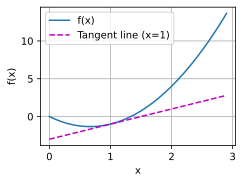

In [9]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

### 偏导数

微分的思想推广到多元函数（multivariate function）

###  梯度
我们可以连结一个多元函数对其所有变量的偏导数，以得到该函数的梯度（gradient）向量。
具体而言，设函数 f:$R^n$ $\rightarrow$ R 的输入是一个n维向量x = [$x_1$,$x_2$,...,$x_n$]$^T$，并且输出是一个标量。 函数f(x)相对于x的梯度, 是一个包含n个偏导数的向量:
$$
\nabla_{\mathbf{x}} f(\mathbf{x}) = \left[\frac{\partial f(\mathbf{x})}{\partial x_1}, \frac{\partial f(\mathbf{x})}{\partial x_2}, \ldots, \frac{\partial f(\mathbf{x})}{\partial x_n}\right]^\top
$$


### 2.4.4. 链式法则

在深度学习中，仅凭上面的梯度求解方法，很难找到梯度。这是因为在深度学习中，多元函数通常是复合（composite）的，所以难以应用上述任何规则来微分这些函数。 幸运的是，链式法则可以被用来微分复合函数。

### 2.4.5 总结
- 微分和积分是微积分的两个分支，前者可以应用于深度学习中的优化问题。

- 导数可以被解释为函数相对于其变量的瞬时变化率，它也是函数曲线的切线的斜率。

- 梯度是一个向量，其分量是多变量函数相对于其所有变量的偏导数。

- 链式法则可以用来微分复合函数。

## 2.5 自动微分 automatic differentiation

深度学习框架通过自动计算导数，即自动微分（automatic differentiation）来加快求导。   

实际中，根据设计好的模型，系统会构建一个计算图（computational graph）， 来跟踪计算是哪些数据通过哪些操作组合起来产生输出。  

自动微分使系统能够随后反向传播梯度。 这里，反向传播（backpropagate）意味着跟踪整个计算图，填充关于每个参数的偏导数。

In [12]:
import torch

x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [13]:
x.requires_grad_(True)
print(x.grad)

None


In [14]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [15]:
y.backward() # 反向传播
x.grad

tensor([ 0.,  4.,  8., 12.])

In [16]:
x.grad == 4 * x

tensor([True, True, True, True])

### 2.5.2. 非标量变量的反向传播